# Particle Filter for DSGE Models

**Notebook 1 of 3** - Application of the particle filter to a New Keynesian DSGE.

We treat the output gap, inflation and interest rate as latent states that
evolve according to a 3-equation New Keynesian model (IS curve, Phillips
curve, Taylor rule) and are observed with measurement noise.  The Bootstrap
particle filter recovers the latent macroeconomic states from the noisy
observations.

While a linearised DSGE could be filtered with the Kalman filter, the
particle filter is essential when the model is non-linear (Zero Lower
Bound, occasionally binding constraints, second-order approximation, etc.).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from particlefilterbox.core.config import PFConfig
from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.filters import BootstrapPF

rng_seed = 20260422
DATA_DIR = Path('..') / 'data'
df = pd.read_csv(DATA_DIR / 'treasury_yields.csv')
df.head()

,t,output_gap_obs,inflation_obs,interest_rate_obs,output_gap_true,inflation_true,interest_rate_true
0,0,-0.230017,-0.013731,-0.219254,0.000000,0.000000,0.000000
1,1,0.172867,-0.174480,-0.058619,0.030472,-0.094857,-0.003812
2,2,-0.114815,0.126035,-0.023718,0.121481,-0.206088,-0.146906
3,3,0.008858,-0.165826,-0.087650,0.122117,-0.098033,-0.142958
4,4,-0.100320,-0.053578,-0.022513,0.024601,0.046304,-0.047405


## 1. The 3-equation New Keynesian model

The latent state vector is $x_t=(\tilde y_t,\pi_t,r_t)^\top$, where
$\tilde y_t$ is the output gap, $\pi_t$ the inflation rate and $r_t$ the
policy rate.  In reduced-form the linearised system reads

$$
\begin{aligned}
\tilde y_t &= 0.9\,\tilde y_{t-1} + \varepsilon^x_t,\\
\pi_t      &= 0.5\,\pi_{t-1} + 0.3\,\tilde y_t + \varepsilon^\pi_t,\\
r_t        &= 0.8\,r_{t-1} + 0.5\,\pi_t + 0.2\,\tilde y_t + \varepsilon^r_t,
\end{aligned}
$$

with mutually independent Gaussian shocks.  The observation equation adds
i.i.d. measurement noise to each component:

$$
y_t = x_t + \eta_t,\qquad \eta_t \sim \mathcal{N}(0,R).
$$

These are the same parameters that generated `treasury_yields.csv`.

In [2]:
class NewKeynesianDSGE(ParticleFilterModel):
    """Latent IS / Phillips / Taylor system with Gaussian observation noise."""

    k_states = 3
    k_obs = 3

    def __init__(self) -> None:
        # Transition coefficients (match generate_data.py).
        self.rho_x = 0.9
        self.rho_pi = 0.5
        self.kappa = 0.3
        self.rho_r = 0.8
        self.phi_pi = 0.5
        self.phi_x = 0.2
        # Shock standard deviations.
        self.sigma_x = 0.1
        self.sigma_pi = 0.1
        self.sigma_r = 0.05
        # Measurement std for (output_gap, inflation, interest rate).
        self.R_std = np.array([0.20, 0.15, 0.10])

    @property
    def params(self) -> dict[str, float]:
        return {
            'rho_x': self.rho_x, 'rho_pi': self.rho_pi, 'kappa': self.kappa,
            'rho_r': self.rho_r, 'phi_pi': self.phi_pi, 'phi_x': self.phi_x,
            'sigma_x': self.sigma_x, 'sigma_pi': self.sigma_pi, 'sigma_r': self.sigma_r,
        }

    def initial_distribution(self, n_particles, rng):
        # Stationary distribution near zero with mild dispersion.
        return rng.normal(0.0, 0.3, size=(n_particles, self.k_states))

    def transition(self, particles, t, rng):
        x_prev, pi_prev, r_prev = particles[:, 0], particles[:, 1], particles[:, 2]
        eps_x = rng.standard_normal(particles.shape[0]) * self.sigma_x
        eps_pi = rng.standard_normal(particles.shape[0]) * self.sigma_pi
        eps_r = rng.standard_normal(particles.shape[0]) * self.sigma_r
        x_new = self.rho_x * x_prev + eps_x
        pi_new = self.rho_pi * pi_prev + self.kappa * x_new + eps_pi
        r_new = self.rho_r * r_prev + self.phi_pi * pi_new + self.phi_x * x_new + eps_r
        return np.column_stack([x_new, pi_new, r_new])

    def log_observation_likelihood(self, particles, y_t, t):
        diff = particles - y_t  # (N, 3)
        var = self.R_std ** 2
        ll = -0.5 * np.sum(diff ** 2 / var, axis=1)
        ll -= 0.5 * np.sum(np.log(2 * np.pi * var))
        return ll

model = NewKeynesianDSGE()
model.params

{'rho_x': 0.9,
 'rho_pi': 0.5,
 'kappa': 0.3,
 'rho_r': 0.8,
 'phi_pi': 0.5,
 'phi_x': 0.2,
 'sigma_x': 0.1,
 'sigma_pi': 0.1,
 'sigma_r': 0.05}

## 2. Run the Bootstrap particle filter

We use $N=2000$ particles and systematic resampling.  The observed series is
the noisy `(output_gap_obs, inflation_obs, interest_rate_obs)` triple.

In [3]:
obs_cols = ['output_gap_obs', 'inflation_obs', 'interest_rate_obs']
true_cols = ['output_gap_true', 'inflation_true', 'interest_rate_true']
Y = df[obs_cols].to_numpy(dtype=float)
X_true = df[true_cols].to_numpy(dtype=float)

config = PFConfig(n_particles=2000, resampling='systematic', ess_threshold=0.5, seed=rng_seed)
pf = BootstrapPF(model=model, config=config)
result = pf.filter(Y)

print(f'log-likelihood : {result.log_likelihood:.2f}')
print(f'mean ESS       : {result.ess_history.mean():.1f}')
print(f'resample share : {result.resampled.mean():.1%}')

log-likelihood : 359.30
mean ESS       : 1791.0
resample share : 73.8%


## 3. Filtered states vs. ground truth

The plots below compare each component of the filtered mean state with the
true latent path used to simulate the data.  The filter de-noises the
observations by exploiting the cross-equation structure of the DSGE.

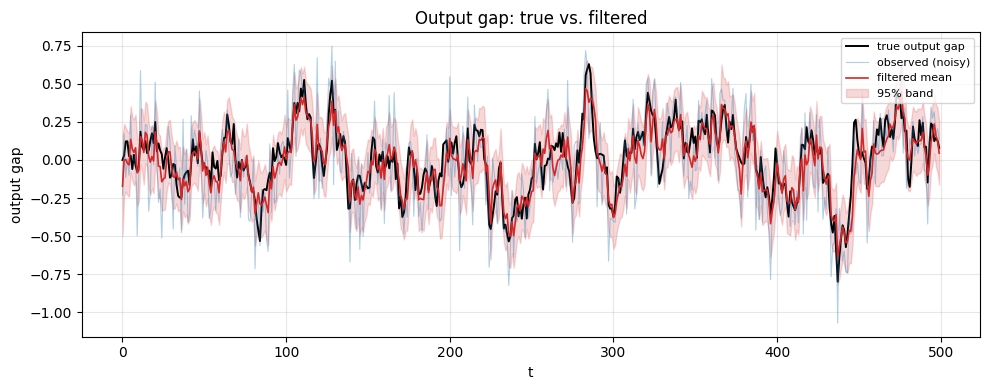

In [4]:
filtered = result.filtered_means  # (T, 3)
filtered_std = np.sqrt(np.maximum(np.diagonal(result.filtered_covs, axis1=1, axis2=2), 0.0))
t_axis = df['t'].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_axis, X_true[:, 0], color='black', lw=1.4, label='true output gap')
ax.plot(t_axis, Y[:, 0], color='C0', alpha=0.35, lw=0.8, label='observed (noisy)')
ax.plot(t_axis, filtered[:, 0], color='C3', lw=1.2, label='filtered mean')
ax.fill_between(t_axis, filtered[:, 0] - 1.96 * filtered_std[:, 0],
                filtered[:, 0] + 1.96 * filtered_std[:, 0],
                color='C3', alpha=0.18, label='95% band')
ax.set_title('Output gap: true vs. filtered'); ax.set_xlabel('t'); ax.set_ylabel('output gap')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

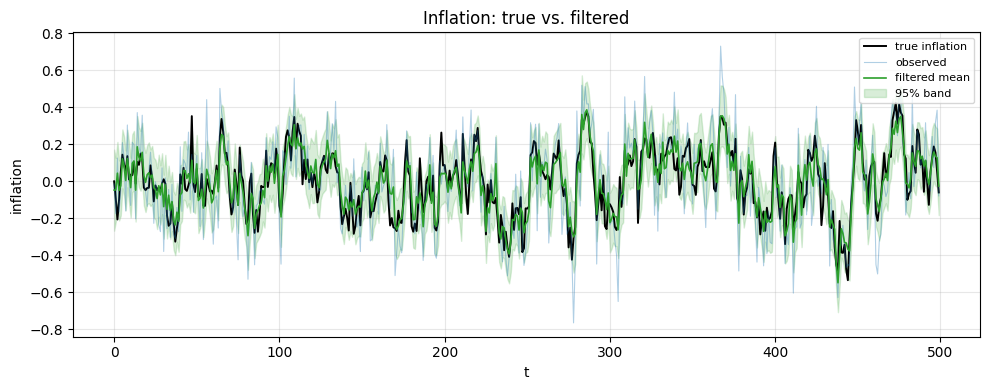

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_axis, X_true[:, 1], color='black', lw=1.4, label='true inflation')
ax.plot(t_axis, Y[:, 1], color='C0', alpha=0.35, lw=0.8, label='observed')
ax.plot(t_axis, filtered[:, 1], color='C2', lw=1.2, label='filtered mean')
ax.fill_between(t_axis, filtered[:, 1] - 1.96 * filtered_std[:, 1],
                filtered[:, 1] + 1.96 * filtered_std[:, 1],
                color='C2', alpha=0.18, label='95% band')
ax.set_title('Inflation: true vs. filtered'); ax.set_xlabel('t'); ax.set_ylabel('inflation')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

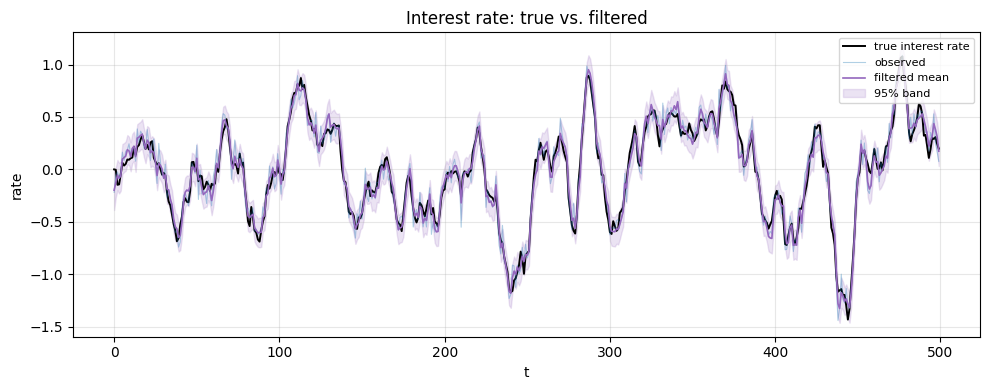

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_axis, X_true[:, 2], color='black', lw=1.4, label='true interest rate')
ax.plot(t_axis, Y[:, 2], color='C0', alpha=0.35, lw=0.8, label='observed')
ax.plot(t_axis, filtered[:, 2], color='C4', lw=1.2, label='filtered mean')
ax.fill_between(t_axis, filtered[:, 2] - 1.96 * filtered_std[:, 2],
                filtered[:, 2] + 1.96 * filtered_std[:, 2],
                color='C4', alpha=0.18, label='95% band')
ax.set_title('Interest rate: true vs. filtered'); ax.set_xlabel('t'); ax.set_ylabel('rate')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Filtering accuracy

We compare the RMSE of the *raw observation* (signal + measurement noise)
with the RMSE of the *filtered mean* against the ground truth.  A reduction
indicates that the filter is exploiting the structural model to extract the
signal from the noise.

In [7]:
names = ['output gap', 'inflation', 'interest rate']
rmse_obs = np.sqrt(np.mean((Y - X_true) ** 2, axis=0))
rmse_filt = np.sqrt(np.mean((filtered - X_true) ** 2, axis=0))
summary = pd.DataFrame({
    'variable': names,
    'rmse_observation': rmse_obs,
    'rmse_filter': rmse_filt,
    'reduction_pct': 100 * (1 - rmse_filt / rmse_obs),
})
summary.round(4)

,variable,rmse_observation,rmse_filter,reduction_pct
0,output gap,0.2025,0.1018,49.7406
1,inflation,0.1526,0.0790,48.2457
2,interest rate,0.1015,0.0688,32.2264


## 5. Particle filter vs. Kalman filter for DSGE

* **Linearised (first order)** DSGEs are Gaussian linear state-space
  models, so the Kalman filter is exact and optimal.  In that setting the
  particle filter is unnecessarily expensive.
* **Higher-order approximations** introduce non-linear policy functions
  (quadratic / cubic terms).  The likelihood is no longer Gaussian and the
  Kalman filter becomes biased; the particle filter remains consistent.
* **Occasionally binding constraints** such as the Zero Lower Bound, or
  regime-switching parameters, also break the Gaussian assumption.  In
  these models the particle filter is the standard choice (see
  Fernandez-Villaverde & Rubio-Ramirez, 2007; Herbst & Schorfheide,
  2015).

The current notebook uses a linearised system; the modest RMSE reduction
above shows that the bootstrap PF, while suboptimal versus the Kalman
filter in this Gaussian case, is competitive even with a finite particle
budget.

## 6. Take-aways
* `particlefilterbox.filters.BootstrapPF` only needs a `transition` and
  `log_observation_likelihood`, making it trivial to plug in an arbitrary
  DSGE.
* For non-linear DSGEs the same code works unchanged; users only need to
  modify the `transition` to call the second-order policy function.
* The cross-equation structure of the DSGE drives most of the noise
  reduction relative to the raw observations.